In [1]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples,noise=0.03,random_state=42)

In [2]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [3]:
import pandas as pd

circles = pd.DataFrame({"X1":X[:,0],
                        "X2":X[:,1],
                        "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

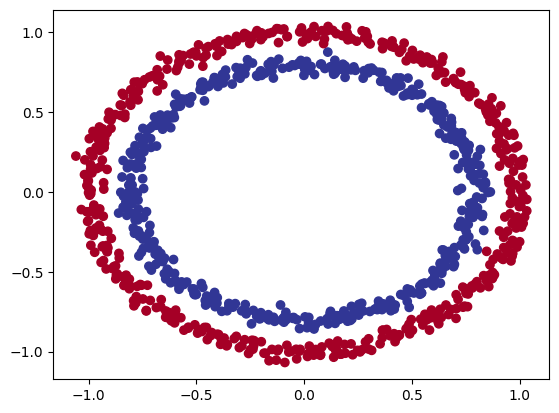

In [5]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [6]:
# Check the shapes of our features and labels
X.shape,y.shape

((1000, 2), (1000,))

In [7]:
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X:{X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of X:{X_sample.shape} and the same for y:{y_sample.shape}") #()表示标量

Values for one sample of X:[0.75424625 0.23148074] and the same for y:1
Shapes for one sample of X:(2,) and the same for y:()


In [8]:
# Turn Data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [10]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
class CirclemodelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        return x
    
model_0 = CirclemodelV0().to(device)
model_0

CirclemodelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions:{len(untrained_preds)},Shape:{untrained_preds.shape}")
print(f"Length of test samples:{len(y_test)},Shape:{y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions:200,Shape:torch.Size([200, 1])
Length of test samples:200,Shape:torch.Size([200])

First 10 predictions:
tensor([[-0.2798],
        [-0.2309],
        [-0.4068],
        [-0.2438],
        [-0.4052],
        [-0.3754],
        [-0.2392],
        [-0.2730],
        [-0.4066],
        [-0.2277]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [14]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [15]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [16]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.2798],
        [-0.2309],
        [-0.4068],
        [-0.2438],
        [-0.4052]], device='cuda:0', grad_fn=<SliceBackward0>)

In [17]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4305],
        [0.4425],
        [0.3997],
        [0.4394],
        [0.4001]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [18]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [19]:
torch.manual_seed(42)

epochs = 100

X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch:{epoch} | Loss:{loss:.5f},Accuracy:{acc:.2f}% | Test loss:{test_loss:.5f}, Test acc:{test_acc:.2f}%")

Epoch:0 | Loss:0.70768,Accuracy:50.00% | Test loss:0.70872, Test acc:50.00%
Epoch:10 | Loss:0.69703,Accuracy:50.00% | Test loss:0.69943, Test acc:50.00%
Epoch:20 | Loss:0.69413,Accuracy:41.88% | Test loss:0.69683, Test acc:40.50%
Epoch:30 | Loss:0.69335,Accuracy:47.88% | Test loss:0.69602, Test acc:46.50%
Epoch:40 | Loss:0.69313,Accuracy:50.12% | Test loss:0.69570, Test acc:45.00%
Epoch:50 | Loss:0.69306,Accuracy:50.50% | Test loss:0.69552, Test acc:45.00%
Epoch:60 | Loss:0.69304,Accuracy:50.38% | Test loss:0.69540, Test acc:46.50%
Epoch:70 | Loss:0.69303,Accuracy:50.75% | Test loss:0.69530, Test acc:47.00%
Epoch:80 | Loss:0.69302,Accuracy:50.88% | Test loss:0.69522, Test acc:47.50%
Epoch:90 | Loss:0.69301,Accuracy:50.50% | Test loss:0.69515, Test acc:47.50%


In [20]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_functions.py is already exists,skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py","wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions,plot_decision_boundary

helper_functions.py is already exists,skipping download


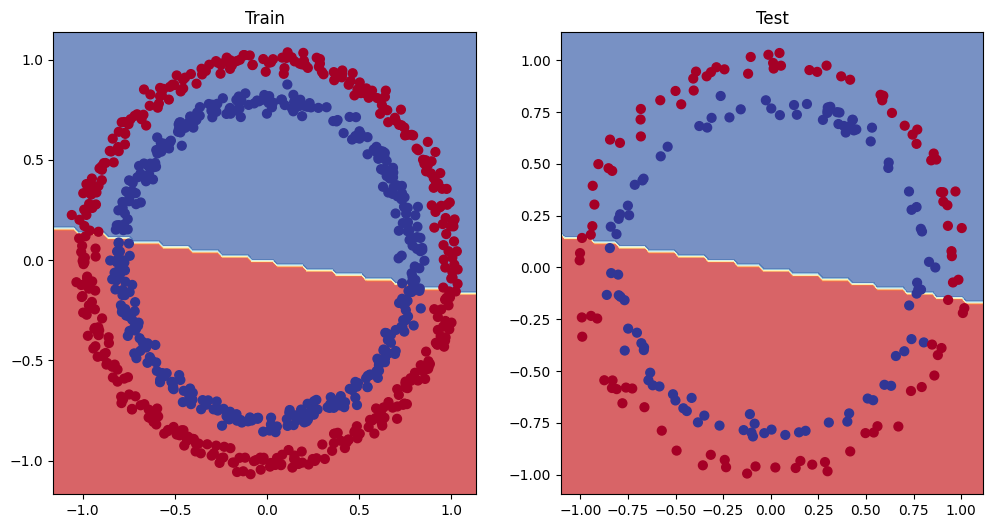

In [21]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)